# CodeAlpha Task 3 — Data Visualization

## Unemployment in India

### Objective

The objective of this project is to transform unemployment data into
clear and meaningful visualizations. The visualizations are designed
to highlight important trends, regional differences, Rural-Urban
patterns, and relationships between key variables.



## Visualization Questions

1. How has unemployment changed over time?
2. Which regions have the highest unemployment rates?
3. How does unemployment differ between Rural and Urban areas?
4. How are employment and unemployment related?
5. What relationships exist between the main numerical variables?

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("Unemployment in India.csv")

df.columns = df.columns.str.strip()

df = df.dropna()

df = df.drop_duplicates()

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 740
Columns: 7


In [12]:
average_unemployment = (
    df.groupby('Date')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
)

average_unemployment.head()

,Date,Estimated Unemployment Rate (%)
0,2019-05-31,8.874259
1,2019-06-30,9.303333
2,2019-07-31,9.033889
3,2019-08-31,9.637925
4,2019-09-30,9.051731


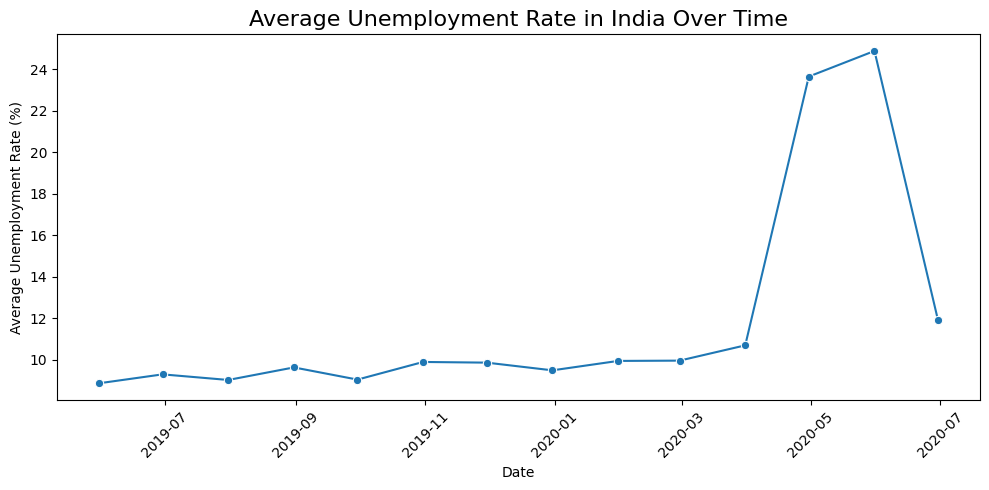

In [14]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=average_unemployment,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    marker='o'
)

plt.title('Average Unemployment Rate in India Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## **Insight**

The line chart shows how the average unemployment rate changes over
time. It helps identify periods of increasing and decreasing
unemployment and makes major fluctuations easier to observe.

In [15]:
region_unemployment = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

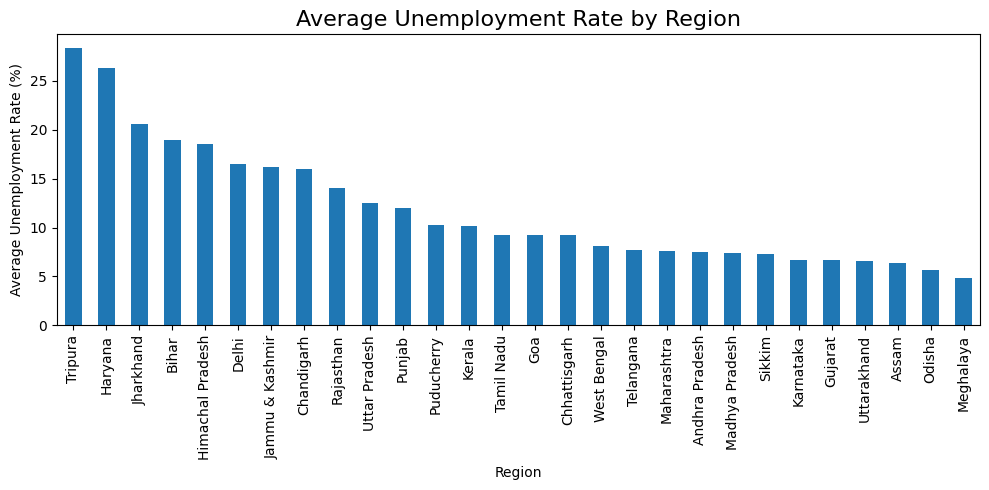

In [17]:
plt.figure(figsize=(10, 5))

region_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate by Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

##**Insight**

The bar chart shows considerable variation in average unemployment
rates across regions. Some regions have noticeably higher average
unemployment rates than others, indicating regional differences in
employment conditions.

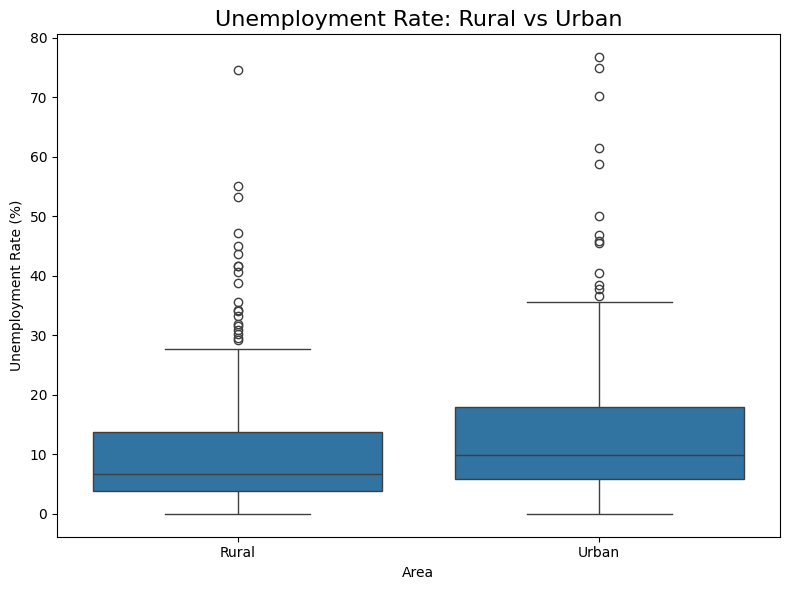

In [18]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='Area',
    y='Estimated Unemployment Rate (%)'
)

plt.title('Unemployment Rate: Rural vs Urban', fontsize=16)
plt.xlabel('Area')
plt.ylabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()

## **Insight**

The boxplot compares the distribution of unemployment rates between
Rural and Urban areas. It shows differences in the central values,
spread, and potential outliers of unemployment observations.

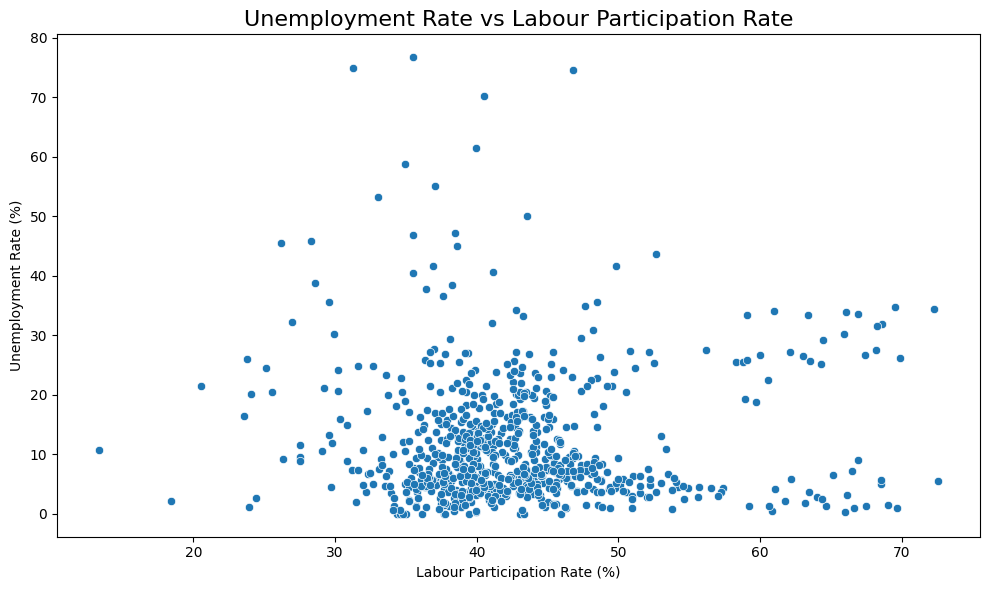

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)'
)

plt.title(
    'Unemployment Rate vs Labour Participation Rate',
    fontsize=16
)

plt.xlabel('Labour Participation Rate (%)')
plt.ylabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()

 ## **Insight**

The scatter plot shows the relationship between labour participation
and unemployment rates. The distribution of points helps identify
whether the variables have a visible relationship and highlights
possible unusual observations.

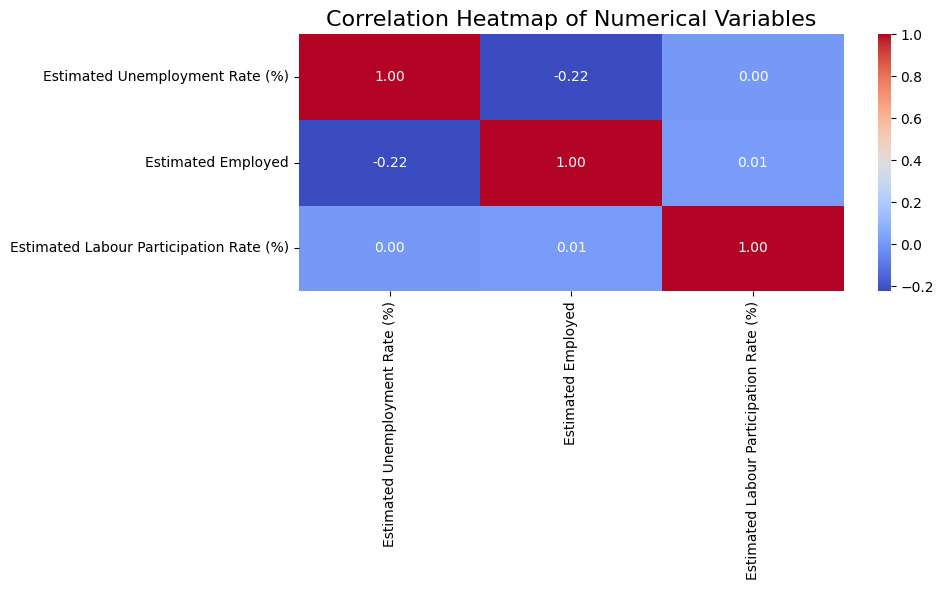

In [20]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16)

plt.tight_layout()
plt.show()

### **Insight**

The correlation heatmap summarizes relationships among the numerical
variables in the dataset. It helps identify variables that move
together and variables with weak linear relationships. Correlation
indicates association and does not by itself prove causation.

# **Conclusion**

The visualizations provide a clear overview of unemployment patterns
in India. The time-series chart highlights changes in unemployment
over time, while the regional bar chart reveals differences between
regions. The Rural-Urban boxplot compares the distribution of
unemployment rates across areas. The scatter plot explores the
relationship between labour participation and unemployment, while
the correlation heatmap summarizes relationships among numerical
variables.

Together, these visualizations transform the raw unemployment dataset
into an understandable data story and help identify important
patterns, differences, and relationships.